# Task 1: Financial AI Analysis Workflow

This notebook implements a practical financial analysis workflow for a Senior Machine Learning Engineer assessment. The focus is not on building a trading system. The focus is on reusable engineering, structured outputs, graceful degradation, and clear explanations.

Task 1 intentionally reuses Task 3 utilities where appropriate:

- market-data and technical-indicator helpers
- volatility calculation
- yfinance news retrieval
- Groq-based headline sentiment
- Pydantic schemas for structured outputs
- trace logging from reusable tools

Notebook-specific code stays in `task1_financial/src/financial_workflow.py`: visualization, final summary generation, and teaching-friendly orchestration.

## 1. Introduction

The workflow answers a focused question: given a ticker, what do recent price behavior, technical indicators, volatility, news, and LLM sentiment suggest about risk and investment outlook?

The output should be easy to inspect. Every major intermediate result is kept visible so the workflow can be discussed in an interview.

## 2. Environment Setup

Set `GROQ_API_KEY` in a local `.env` file if you want live LLM sentiment. If the key is missing, the sentiment tool returns a neutral fallback instead of crashing the notebook.

In [19]:
from pathlib import Path
import sys

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "task1_financial"
    else Path.cwd()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from task1_financial.src.financial_workflow import (
    collect_financial_evidence,
    generate_investment_outlook,
    plot_all_indicators,
    run_task1_analysis,
    save_task1_output,
    validate_reused_outputs,
)

TICKER = "AAPL"
PERIOD = "2y"

## 3. Data Retrieval

This step retrieves price history, structured technical summaries, volatility, news, and sentiment inputs. The helper keeps raw evidence separate from interpretation, which is important for auditability.

In [20]:
evidence = collect_financial_evidence(TICKER, period=PERIOD)
evidence.keys()

[task1] Retrieving market dataframe...
[task1] Retrieving structured price summary...
[task1] Calculating annualized volatility...
[task1] Retrieving recent news...
[task1] Classifying headline sentiment...


dict_keys(['ticker', 'dataframe', 'price_summary', 'volatility', 'news', 'sentiment'])

In [21]:
dataframe = evidence["dataframe"]
dataframe.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_50,SMA_200,RSI_14,MACD,MACD_SIGNAL,BB_UPPER,BB_LOWER
Date,,,,,,,,,,,,,,
2026-05-04 00:00:00-04:00,279.660004,280.630005,274.859985,276.829987,46668400,0.0,0.0,261.463600,255.238604,65.745284,4.559334,3.675739,281.237307,253.277693
2026-05-05 00:00:00-04:00,276.929993,284.570007,276.500000,284.179993,49311700,0.0,0.0,261.823600,255.606807,65.594806,5.248893,3.990370,283.143137,254.439862
2026-05-06 00:00:00-04:00,281.920013,288.029999,281.070007,287.510010,58336100,0.0,0.0,262.131000,255.985181,71.071508,5.994972,4.391290,286.049819,254.394182
2026-05-07 00:00:00-04:00,289.269989,292.130005,285.779999,287.440002,45224300,0.0,0.0,262.395200,256.353633,67.056489,6.505603,4.814153,288.461739,254.677262
2026-05-08 00:00:00-04:00,290.010010,294.760010,290.000000,293.320007,52631200,0.0,0.0,262.802599,256.752732,68.940400,7.300592,5.311441,291.858279,254.564722


## 4. Technical Indicators

The indicator formulas are reused from Task 3 to avoid duplicate logic. The notebook displays the structured summary and validates it against the shared Pydantic schema.

In [22]:
validated_outputs = validate_reused_outputs(evidence)
validated_outputs["price_summary"]

{'ticker': 'AAPL',
 'current_price': 293.32,
 'sma_50': 262.8,
 'sma_200': 256.75,
 'rsi_14': 68.94,
 'macd': 7.3,
 'macd_signal': 5.31,
 'bollinger_upper': 291.86,
 'bollinger_lower': 254.56,
 'momentum_signal': 'Bullish'}

## 5. Volatility Analysis

Annualized volatility gives a compact risk signal. It should not be treated as a prediction; it describes recent variability in returns.

In [23]:
validated_outputs["volatility"]

{'ticker': 'AAPL', 'annualized_volatility': 0.255}

## 6. News & Sentiment Analysis

News comes from yfinance when available. Headline sentiment is classified through Groq using structured JSON outputs. If the API key or endpoint is unavailable, the workflow returns a neutral fallback and explains why.

In [24]:
evidence["news"][:5]

[{'title': "The $1 trillion club's new members are powering the AI boom: Chart of the Day",
  'source': 'Yahoo Finance',
  'published': '2026-05-10T10:42:34Z'},
 {'title': "Dow Jones Futures Fall, Oil Prices Jump To $100; Trump Says Iran Response 'Totally Unacceptable'",
  'source': "Investor's Business Daily",
  'published': '2026-05-11T03:05:22Z'},
 {'title': "590,000 buyers paid $59 million for Trump's gold phone — not 1 has shipped and refunds look unlikely",
  'source': 'Moneywise',
  'published': '2026-05-10T22:35:00Z'},
 {'title': 'Apple’s Higher R&D Signals Deeper AI Push And Investor Reassessment',
  'source': 'Simply Wall St.',
  'published': '2026-05-10T21:17:03Z'},
 {'title': 'Is It Too Late to Buy Apple Stock?',
  'source': 'Motley Fool',
  'published': '2026-05-10T16:02:00Z'}]

In [25]:
evidence["sentiment"]

{'results': [{'headline': "The $1 trillion club's new members are powering the AI boom: Chart of the Day",
   'sentiment': 'positive',
   'confidence': 0.8,
   'reason': "The headline mentions 'powering the AI boom', indicating a positive trend for the companies involved."},
  {'headline': "Dow Jones Futures Fall, Oil Prices Jump To $100; Trump Says Iran Response 'Totally Unacceptable'",
   'sentiment': 'negative',
   'confidence': 0.7,
   'reason': "The headline mentions 'Dow Jones Futures Fall' and 'Totally Unacceptable', indicating a negative market sentiment."},
  {'headline': "590,000 buyers paid $59 million for Trump's gold phone — not 1 has shipped and refunds look unlikely",
   'sentiment': 'negative',
   'confidence': 0.9,
   'reason': "The headline mentions 'not 1 has shipped' and 'refunds look unlikely', indicating a negative sentiment for Trump's business."},
  {'headline': 'Apple’s Higher R&D Signals Deeper AI Push And Investor Reassessment',
   'sentiment': 'positive',
  

## 7. Risk Interpretation

The final interpretation is deterministic and structured. This keeps Task 1 easy to explain: tools collect evidence, the LLM classifies sentiment, and simple business rules summarize risk.

In [26]:
outlook = generate_investment_outlook(evidence)
outlook.model_dump()["risk_interpretation"]

{'volatility_level': 'moderate',
 'momentum_view': 'Bullish',
 'sentiment_view': 'positive',
 'key_risks': ['No single severe risk was detected, but market and company-specific risk remain.']}

## 8. Final Financial Outlook

The final result is a structured Pydantic output. Saving it as JSON makes the notebook reproducible and gives interviewers a concrete artifact to inspect.

In [27]:
outlook.model_dump()

{'ticker': 'AAPL',
 'overall_view': 'constructive but risk-aware',
 'risk_level': 'moderate',
 'technical_summary': 'Momentum signal is Bullish. Current price is 293.32, with SMA-50 at 262.8 and SMA-200 at 256.75.',
 'sentiment_summary': 'Overall sentiment score is 0.2031 (positive).',
 'risk_interpretation': {'volatility_level': 'moderate',
  'momentum_view': 'Bullish',
  'sentiment_view': 'positive',
  'key_risks': ['No single severe risk was detected, but market and company-specific risk remain.']},
 'practical_next_steps': ['Review the latest company filings and earnings context.',
  'Compare this signal against sector and market conditions.',
  'Use conservative sizing when volatility or sentiment risk is elevated.'],
 'generated_at': '2026-05-11T07:57:45.073264+00:00'}

In [28]:
output_path = save_task1_output(TICKER, evidence, outlook)
output_path

WindowsPath('C:/Users/poshi/Documents/My/Interview-quiz/cdazzdev-mla/task1_financial/outputs/AAPL_task1_report_20260511_075745.json')

## 9. Visualization of Key Indicators

The required visualizations are created with matplotlib:

1. price + SMA 50/SMA 200
2. RSI
3. MACD
4. Bollinger Bands

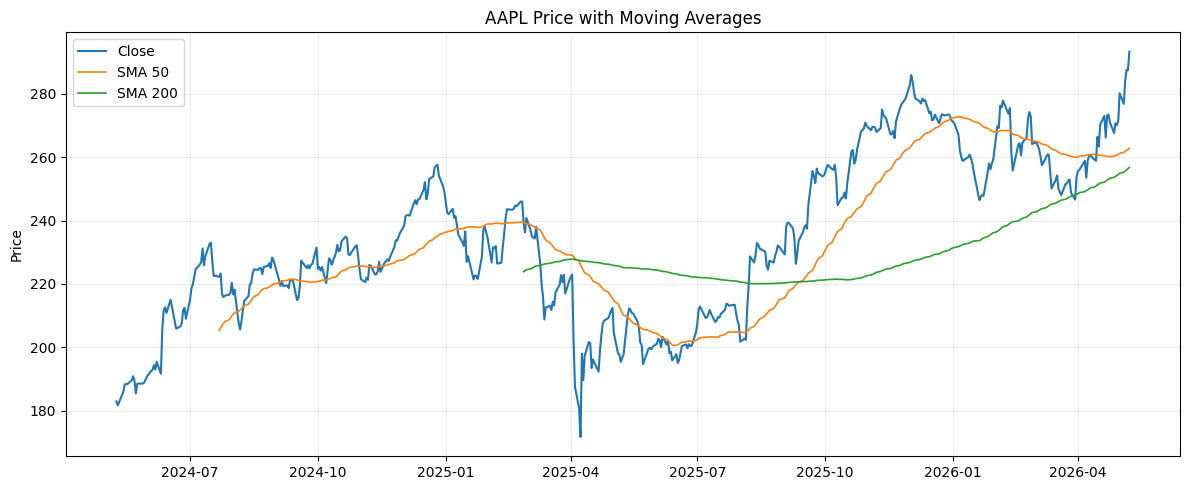

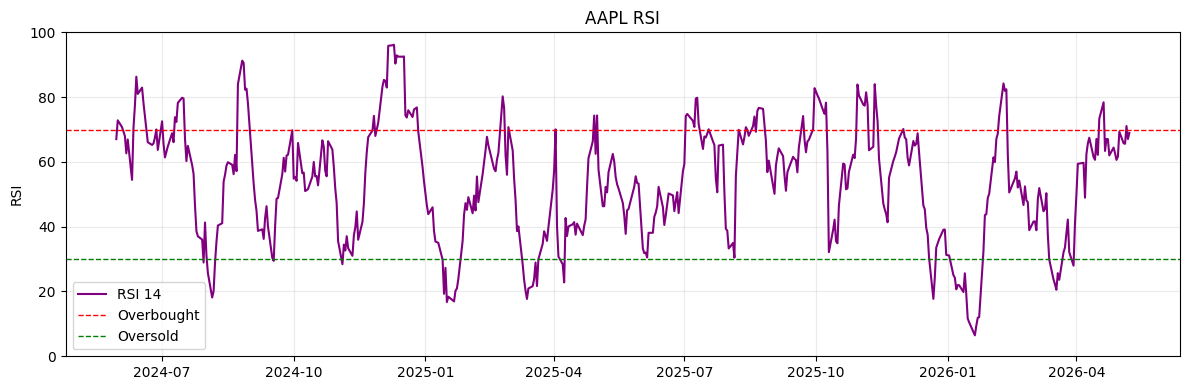

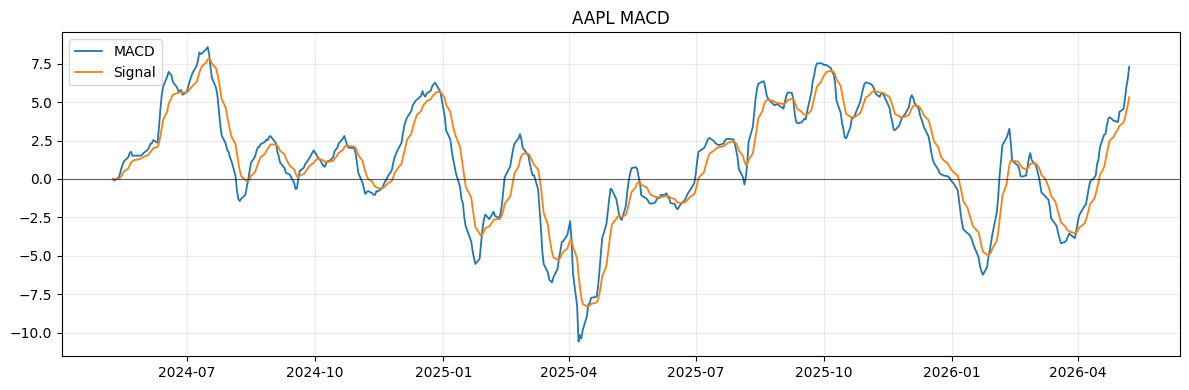

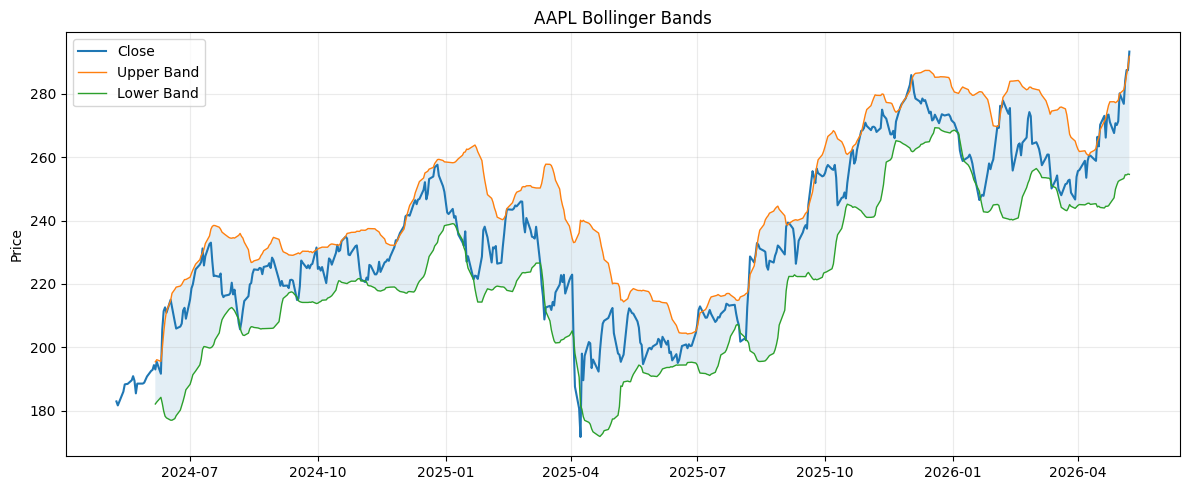

In [29]:
figures = plot_all_indicators(dataframe, TICKER)

## 10. Single-Call Workflow Option

For demos, the full Task 1 workflow can be run with one helper. The earlier cells are kept separate so the engineering decisions remain visible.

In [30]:
result = run_task1_analysis("MSFT", period="2y")
result["outlook"]

[task1] Retrieving market dataframe...
[task1] Retrieving structured price summary...
[task1] Calculating annualized volatility...
[task1] Retrieving recent news...
[task1] Classifying headline sentiment...
[task1] Saved structured report to C:\Users\poshi\Documents\My\Interview-quiz\cdazzdev-mla\task1_financial\outputs\MSFT_task1_report_20260511_075750.json


{'ticker': 'MSFT',
 'overall_view': 'cautious',
 'risk_level': 'moderate',
 'technical_summary': 'Momentum signal is Bearish. Current price is 415.12, with SMA-50 at 398.15 and SMA-200 at 464.37.',
 'sentiment_summary': 'Overall sentiment score is 0.1026 (neutral).',
 'risk_interpretation': {'volatility_level': 'moderate',
  'momentum_view': 'Bearish',
  'sentiment_view': 'neutral',
  'key_risks': ['Technical momentum is bearish based on current indicators.']},
 'practical_next_steps': ['Review the latest company filings and earnings context.',
  'Compare this signal against sector and market conditions.',
  'Use conservative sizing when volatility or sentiment risk is elevated.'],
 'generated_at': '2026-05-11T07:57:50.155298+00:00'}

## 11. Engineering Reflection

### Design tradeoffs

This notebook uses a lightweight explicit workflow instead of an autonomous planner. That makes it easier to debug, easier to explain, and safer for a technical assessment.

### Reuse from Task 3

Task 1 reuses Task 3 tools for technical indicators, volatility, news retrieval, sentiment classification, structured schemas, and trace logging. This avoids duplicate implementations and keeps one source of truth for shared logic.

### Notebook-specific parts

Visualization, final explanatory summary, and teaching-oriented orchestration stay in Task 1. These are presentation and analysis concerns, not reusable agent-system infrastructure.

### Limitations of free-tier APIs

yfinance news can be sparse or inconsistent. DuckDuckGo/search-style endpoints may rate-limit. Groq free-tier calls may fail, rate-limit, or return imperfect JSON. The workflow handles this with fallbacks and visible explanations.

### Structured outputs

Pydantic schemas make outputs predictable. This matters because downstream code, notebooks, and evaluators should not parse free-form text when a stable structure is possible.

### Graceful degradation

A missing API key should not break the entire notebook. The workflow returns neutral sentiment or explicit fallback text so the user can still inspect price and volatility evidence.

### Production considerations

A production version would add caching, retries with backoff, stronger API monitoring, more robust source ranking, formal tests, and clearer separation between research output and investment advice.